# COSC2669 Individual Task 1 — Part 1.3 Data Analysis

**Case study:** Junior Data Scientist, Australian Epilepsy Project  
**Datasets:** BEED: Bangalore EEG Epilepsy Dataset and EEG Eye State  
**Algorithms:** K-Nearest Neighbours (KNN) and Support Vector Machine (SVM)

## TL;DR

- On the balanced four-class BEED holdout, tuned KNN achieved **0.983 macro F1**, outperforming SVM (**0.819 macro F1**).
- On EEG Eye State, a blocked group holdout produced much lower and more credible results: KNN **0.637 macro F1** and SVM **0.648 macro F1**.
- A naive random split inflated Eye State macro F1 to approximately **0.961 for KNN** and **0.950 for SVM**, demonstrating temporal leakage from neighbouring measurements.
- The datasets provide complementary evidence: BEED addresses epilepsy-related classification, whereas Eye State tests classification of normal EEG variation. Neither dataset alone validates performance for Australian patients.

## Context & Methods

The two datasets are analysed separately because their attributes and target definitions differ. Both algorithms are new relative to the author's earlier Logistic Regression, Decision Tree and Random Forest work.

**Sources:** [BEED — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/1134/beed%3A%2Bbangalore%2Beeg%2Bepilepsy%2Bdataset) and [EEG Eye State — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/264/eeg+eye+state).

### Evaluation design

- **BEED:** stratified 80/20 train-test split. Four-fold stratified cross-validation on the training set selects hyperparameters using macro F1.
- **EEG Eye State:** rows are sequential samples from one continuous recording. Approximate one-second groups (128 consecutive rows) are kept together using stratified group splitting. This reduces leakage from adjacent measurements. Four-fold stratified group cross-validation selects hyperparameters using macro F1.
- **Preprocessing:** StandardScaler for BEED. QuantileTransformer for Eye State because extreme sensor spikes would dominate distance-based and kernel models. All preprocessing is fitted inside pipelines using training data only.
- **Metrics:** accuracy, balanced accuracy, macro precision, macro recall and macro F1, plus confusion matrices. Macro metrics treat every class equally and help reveal whether a model neglects any target class.

### Key assumptions and limitations

- BEED's supplied file contains numeric labels 0–3 but no subject identifiers; the split cannot guarantee patient-independent evaluation.
- Eye State is a limited continuous recording rather than an independent-patient clinical cohort. Grouping consecutive samples improves the test but does not create external validation.
- Results support an educational comparison only; they are not evidence that either model is ready for clinical diagnosis.

## Setup

In [1]:
from pathlib import Path
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

import sklearn
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    StratifiedKFold,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
})

{'python': '3.12.13', 'pandas': '2.2.3', 'scikit_learn': '1.8.0'}


mkdir -p failed for path /root/.config/matplotlib: [Errno 30] Read-only file system: '/root/.config'
Matplotlib created a temporary cache directory at /tmp/matplotlib-sev03k73 because there was an issue with the default path (/root/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


### Locate the supplied files

Place `BEED_Data.csv` and `EEG Eye State.arff` beside this notebook. The fallback `upload/` path allows the notebook to run in the original workspace.

In [2]:
def locate_file(filename):
    candidates = [
        Path.cwd() / filename,
        Path.cwd() / "upload" / filename,
        Path("/content") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Place it beside the notebook and rerun."
    )

beed_path = locate_file("BEED_Data.csv")
eye_path = locate_file("EEG Eye State.arff")
print("BEED:", beed_path)
print("Eye State:", eye_path)

BEED: /workspace/scratch/5968776b69ae/upload/BEED_Data.csv
Eye State: /workspace/scratch/5968776b69ae/upload/EEG Eye State.arff


## Data

In [3]:
beed = pd.read_csv(beed_path)

eye_raw, eye_metadata = arff.loadarff(eye_path)
eye = pd.DataFrame(eye_raw)
eye["eyeDetection"] = eye["eyeDetection"].str.decode("utf-8").astype(int)

display(beed.head(3))
display(eye.head(3))

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0


### Validate dimensions, missing values, duplicates and class balance

In [4]:
def quality_row(name, frame, target):
    return {
        "dataset": name,
        "rows": len(frame),
        "predictors": frame.shape[1] - 1,
        "target": target,
        "missing_values": int(frame.isna().sum().sum()),
        "duplicate_rows": int(frame.duplicated().sum()),
        "class_counts": frame[target].value_counts().sort_index().to_dict(),
    }

quality = pd.DataFrame([
    quality_row("BEED", beed, "y"),
    quality_row("EEG Eye State", eye, "eyeDetection"),
])
display(quality)

assert beed.shape == (8000, 17)
assert eye.shape == (14980, 15)
assert quality["missing_values"].sum() == 0
assert quality["duplicate_rows"].sum() == 0

,dataset,rows,predictors,target,missing_values,duplicate_rows,class_counts
0,BEED,8000,16,y,0,0,"{0: 2000, 1: 2000, 2: 2000, 3: 2000}"
1,EEG Eye State,14980,14,eyeDetection,0,0,"{0: 8257, 1: 6723}"


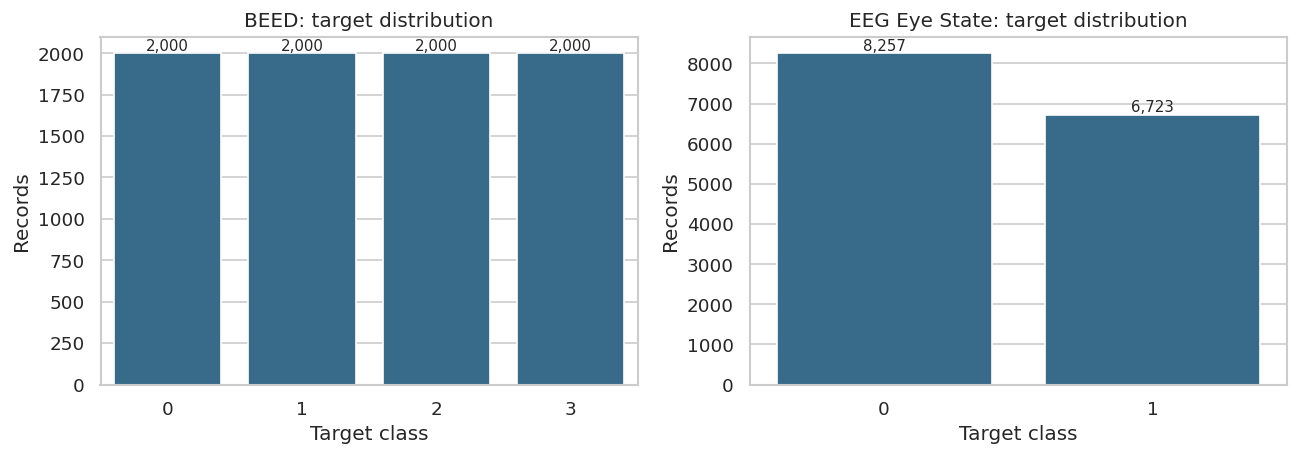

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, frame, target) in zip(
    axes,
    [("BEED", beed, "y"), ("EEG Eye State", eye, "eyeDetection")],
):
    counts = frame[target].value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, color="#2A6F97")
    ax.set_title(f"{name}: target distribution")
    ax.set_xlabel("Target class")
    ax.set_ylabel("Records")
    for patch, value in zip(ax.patches, counts.values):
        ax.text(patch.get_x() + patch.get_width()/2, value, f"{value:,}",
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### Check Eye State sensor extremes

In [6]:
eye_features = eye.drop(columns="eyeDetection")
eye_ranges = pd.DataFrame({
    "min": eye_features.min(),
    "q01": eye_features.quantile(0.01),
    "median": eye_features.median(),
    "q99": eye_features.quantile(0.99),
    "max": eye_features.max(),
})
eye_ranges["full_range_to_middle_98pct"] = (
    (eye_ranges["max"] - eye_ranges["min"])
    / (eye_ranges["q99"] - eye_ranges["q01"])
)
display(eye_ranges.sort_values("full_range_to_middle_98pct", ascending=False).head(8))

,min,q01,median,q99,max,full_range_to_middle_98pct
FC5,2453.3300,4085.6400,4120.51,4196.4100,642564.00,5778.736752
O1,2086.1500,4037.9500,4070.26,4149.2300,567179.00,5078.116912
AF4,1366.1500,4267.1800,4354.87,4488.3171,715897.00,3231.166774
P7,2768.2100,4583.0800,4617.95,4700.0000,362564.00,3077.281817
P8,1357.9500,4167.1800,4199.49,4269.7400,265641.00,2576.862812
AF3,1030.7700,4223.0800,4294.36,4436.6263,309231.00,1443.247811
F8,86.6667,4511.4687,4603.08,4715.3800,152308.00,746.507591
F3,1040.0000,4223.5900,4262.56,4348.7200,6880.51,46.675537


Several Eye State channels contain extreme spikes far outside their central ranges. Quantile transformation is therefore fitted inside each training fold to reduce their influence without using test-set information.

## Results

### Create leakage-aware train-test splits

In [7]:
# BEED: balanced random stratified holdout
X_beed = beed.drop(columns="y")
y_beed = beed["y"]
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_beed,
    y_beed,
    test_size=0.20,
    stratify=y_beed,
    random_state=RANDOM_STATE,
)

# Eye State: keep approximate one-second blocks together
X_eye = eye.drop(columns="eyeDetection")
y_eye = eye["eyeDetection"]
eye_groups = np.arange(len(eye)) // 128
eye_outer_split = StratifiedGroupKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)
eye_train_index, eye_test_index = next(
    eye_outer_split.split(X_eye, y_eye, groups=eye_groups)
)
Xe_train = X_eye.iloc[eye_train_index]
Xe_test = X_eye.iloc[eye_test_index]
ye_train = y_eye.iloc[eye_train_index]
ye_test = y_eye.iloc[eye_test_index]
eye_train_groups = eye_groups[eye_train_index]

split_summary = pd.DataFrame([
    {
        "dataset": "BEED",
        "train_rows": len(Xb_train),
        "test_rows": len(Xb_test),
        "test_class_counts": yb_test.value_counts().sort_index().to_dict(),
    },
    {
        "dataset": "EEG Eye State",
        "train_rows": len(Xe_train),
        "test_rows": len(Xe_test),
        "test_class_counts": ye_test.value_counts().sort_index().to_dict(),
    },
])
display(split_summary)

,dataset,train_rows,test_rows,test_class_counts
0,BEED,6400,1600,"{0: 400, 1: 400, 2: 400, 3: 400}"
1,EEG Eye State,11908,3072,"{0: 1695, 1: 1377}"


### Tune KNN and SVM using training data only

In [8]:
def tune_models(X_train, y_train, preprocessor, cv, groups=None):
    specifications = {
        "KNN": (
            KNeighborsClassifier(),
            {
                "model__n_neighbors": [3, 5, 9, 15],
                "model__weights": ["uniform", "distance"],
            },
        ),
        "SVM": (
            SVC(kernel="rbf"),
            {"model__C": [0.1, 1, 10], "model__gamma": ["scale"]},
        ),
    }

    fitted = {}
    tuning_rows = []
    for model_name, (model, parameter_grid) in specifications.items():
        pipeline = Pipeline([
            ("preprocessing", preprocessor),
            ("model", model),
        ])
        search = GridSearchCV(
            pipeline,
            parameter_grid,
            scoring="f1_macro",
            cv=cv,
            n_jobs=1,
            refit=True,
        )
        search.fit(X_train, y_train, groups=groups)
        fitted[model_name] = search.best_estimator_
        tuning_rows.append({
            "model": model_name,
            "best_parameters": search.best_params_,
            "training_cv_macro_f1": search.best_score_,
        })
    return fitted, pd.DataFrame(tuning_rows)

beed_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=43)
beed_models, beed_tuning = tune_models(
    Xb_train, yb_train, StandardScaler(), beed_cv
)

eye_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=43)
eye_models, eye_tuning = tune_models(
    Xe_train,
    ye_train,
    QuantileTransformer(
        n_quantiles=500,
        output_distribution="normal",
        random_state=RANDOM_STATE,
    ),
    eye_cv,
    groups=eye_train_groups,
)

beed_tuning.insert(0, "dataset", "BEED")
eye_tuning.insert(0, "dataset", "EEG Eye State")
tuning_results = pd.concat([beed_tuning, eye_tuning], ignore_index=True)
display(tuning_results)

,dataset,model,best_parameters,training_cv_macro_f1
0,BEED,KNN,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.962931
1,BEED,SVM,"{'model__C': 10, 'model__gamma': 'scale'}",0.812256
2,EEG Eye State,KNN,"{'model__n_neighbors': 5, 'model__weights': 'u...",0.728885
3,EEG Eye State,SVM,"{'model__C': 10, 'model__gamma': 'scale'}",0.772250


### Evaluate the untouched holdouts

In [9]:
def metric_row(dataset, model_name, y_true, y_pred):
    return {
        "dataset": dataset,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro"),
        "macro_recall": recall_score(y_true, y_pred, average="macro"),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

evaluations = []
predictions = {}
evaluation_inputs = [
    ("BEED", beed_models, Xb_test, yb_test),
    ("EEG Eye State", eye_models, Xe_test, ye_test),
]

for dataset, models, X_test, y_test in evaluation_inputs:
    for model_name, model in models.items():
        predicted = model.predict(X_test)
        predictions[(dataset, model_name)] = predicted
        evaluations.append(
            metric_row(dataset, model_name, y_test, predicted)
        )

metrics = pd.DataFrame(evaluations)
display(metrics.round(4))

,dataset,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,BEED,KNN,0.9831,0.9831,0.9836,0.9831,0.9832
1,BEED,SVM,0.8231,0.8231,0.8418,0.8231,0.8194
2,EEG Eye State,KNN,0.6393,0.6373,0.6364,0.6373,0.6366
3,EEG Eye State,SVM,0.6484,0.6500,0.6484,0.6500,0.6475


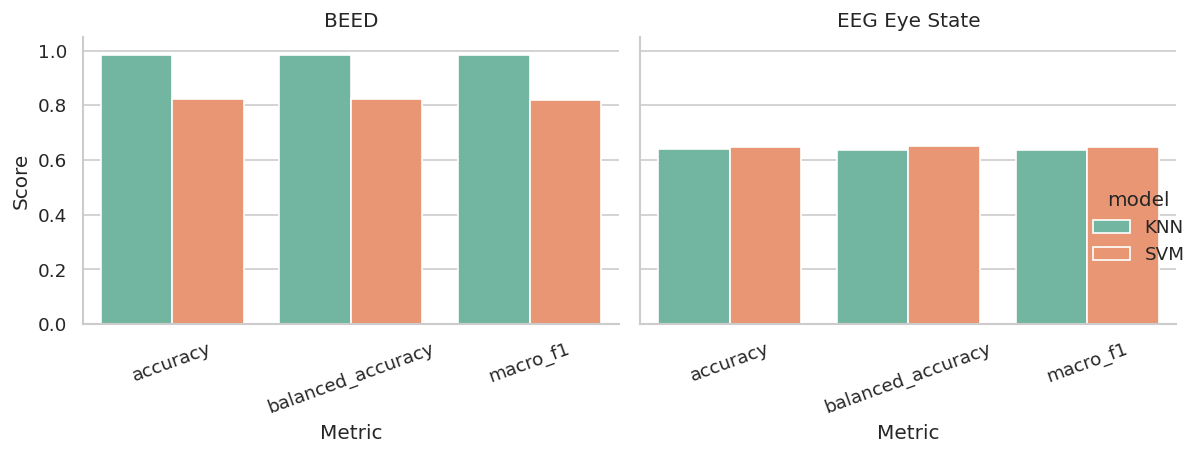

In [10]:
metric_plot = metrics.melt(
    id_vars=["dataset", "model"],
    value_vars=["accuracy", "balanced_accuracy", "macro_f1"],
    var_name="metric",
    value_name="score",
)
g = sns.catplot(
    data=metric_plot,
    x="metric",
    y="score",
    hue="model",
    col="dataset",
    kind="bar",
    height=4,
    aspect=1.15,
    palette="Set2",
)
g.set_axis_labels("Metric", "Score")
g.set(ylim=(0, 1.05))
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Confusion matrices

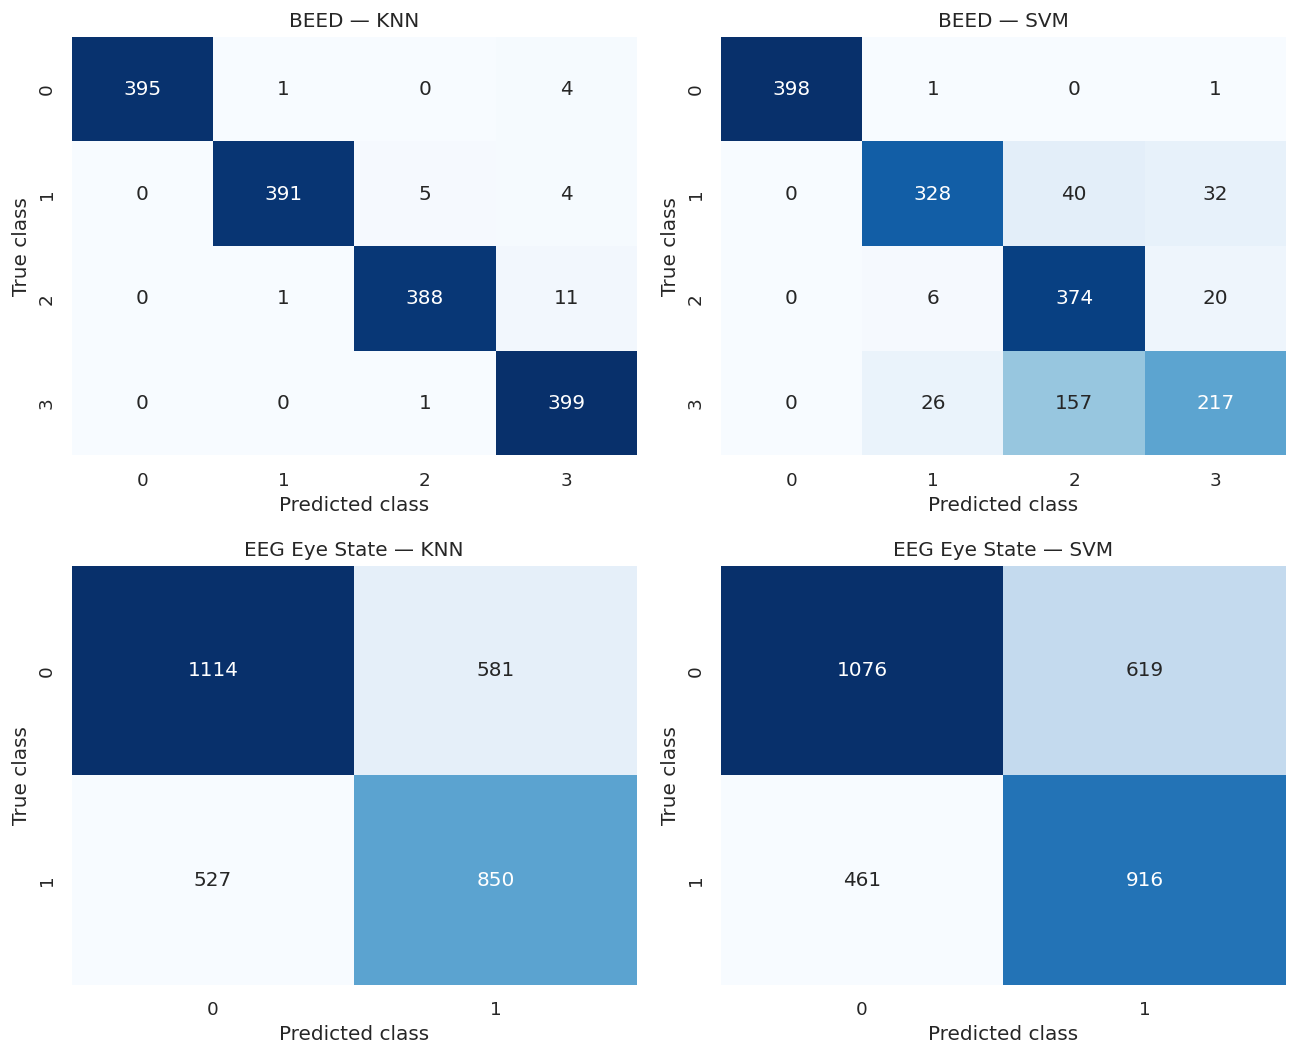

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (dataset, model_name) in zip(
    axes.flat,
    [("BEED", "KNN"), ("BEED", "SVM"),
     ("EEG Eye State", "KNN"), ("EEG Eye State", "SVM")],
):
    y_true = yb_test if dataset == "BEED" else ye_test
    labels = sorted(y_true.unique())
    matrix = confusion_matrix(
        y_true, predictions[(dataset, model_name)], labels=labels
    )
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=labels,
        yticklabels=labels,
    )
    ax.set_title(f"{dataset} — {model_name}")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
plt.tight_layout()
plt.show()

### Model-agnostic permutation importance

In [12]:
importance_rows = []
importance_inputs = [
    ("BEED", beed_models, Xb_test, yb_test),
    ("EEG Eye State", eye_models, Xe_test, ye_test),
]
for dataset, models, X_test, y_test in importance_inputs:
    for model_name, model in models.items():
        result = permutation_importance(
            model,
            X_test,
            y_test,
            scoring="f1_macro",
            n_repeats=5,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
        for feature, mean, std in zip(
            X_test.columns,
            result.importances_mean,
            result.importances_std,
        ):
            importance_rows.append({
                "dataset": dataset,
                "model": model_name,
                "feature": feature,
                "importance_mean": mean,
                "importance_std": std,
            })

importance = pd.DataFrame(importance_rows)
top_features = (
    importance.sort_values(
        ["dataset", "model", "importance_mean"],
        ascending=[True, True, False],
    )
    .groupby(["dataset", "model"], as_index=False)
    .head(5)
)
display(top_features.round(4))

,dataset,model,feature,importance_mean,importance_std
4,BEED,KNN,X5,0.1421,0.0041
11,BEED,KNN,X12,0.1415,0.0058
3,BEED,KNN,X4,0.1235,0.0112
12,BEED,KNN,X13,0.1183,0.0042
10,BEED,KNN,X11,0.1137,0.0034
27,BEED,SVM,X12,0.1129,0.0088
26,BEED,SVM,X11,0.1095,0.0056
16,BEED,SVM,X1,0.1084,0.0075
31,BEED,SVM,X16,0.1035,0.0055
30,BEED,SVM,X15,0.1033,0.0030


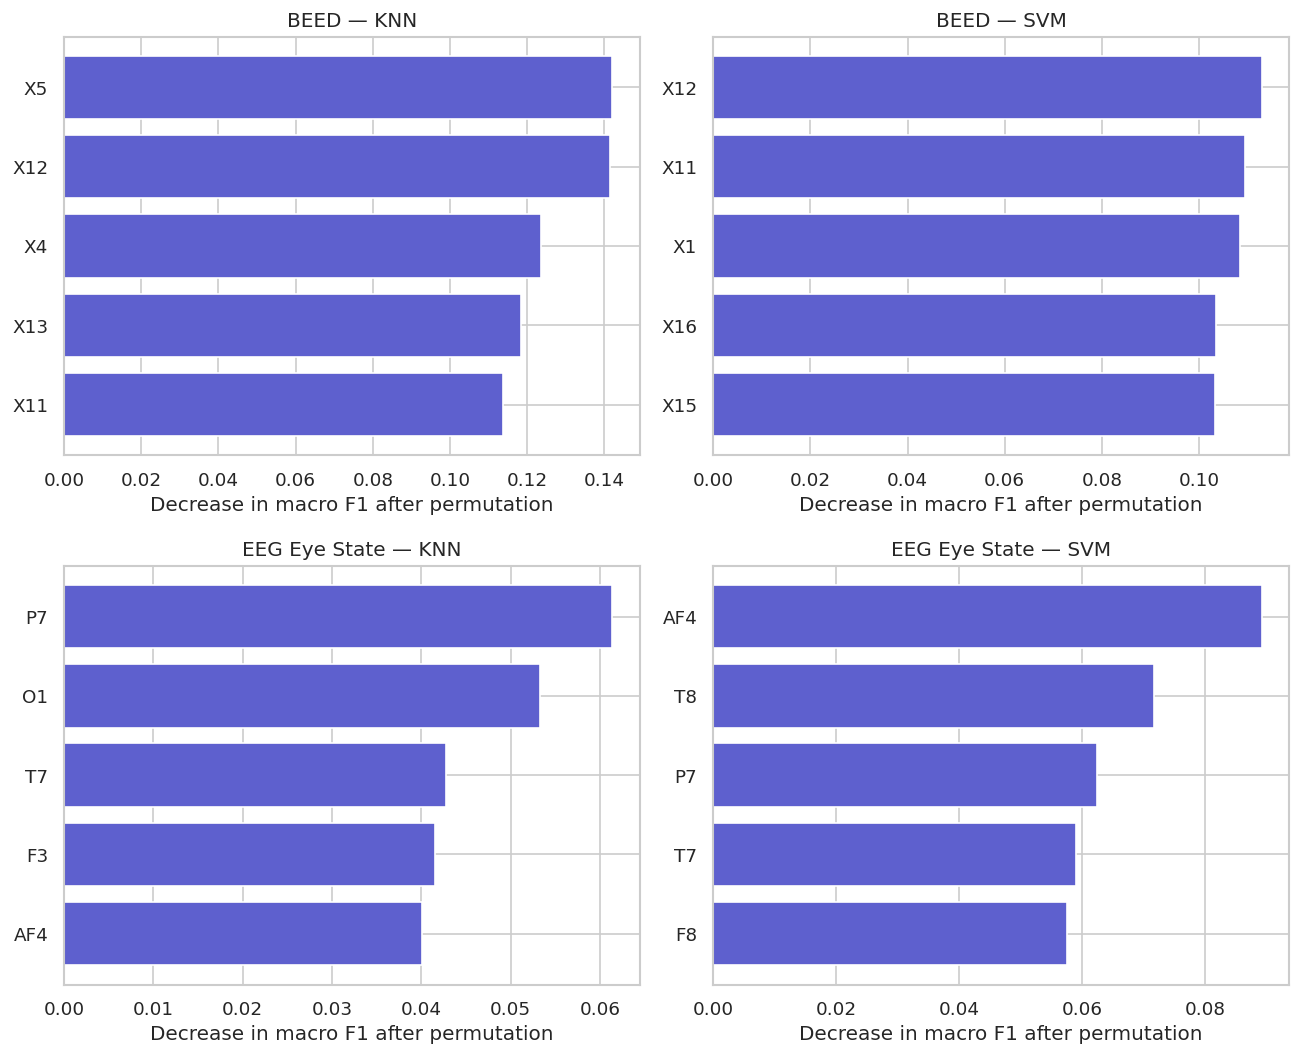

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
combinations = [
    ("BEED", "KNN"), ("BEED", "SVM"),
    ("EEG Eye State", "KNN"), ("EEG Eye State", "SVM"),
]
for ax, (dataset, model_name) in zip(axes.flat, combinations):
    subset = top_features[
        (top_features["dataset"] == dataset)
        & (top_features["model"] == model_name)
    ].sort_values("importance_mean")
    ax.barh(subset["feature"], subset["importance_mean"], color="#5E60CE")
    ax.set_title(f"{dataset} — {model_name}")
    ax.set_xlabel("Decrease in macro F1 after permutation")
plt.tight_layout()
plt.show()

### Sensitivity check: random versus blocked Eye State split

,model,split,macro_f1
0,KNN,Random rows,0.9609
1,KNN,Blocked groups,0.6366
2,SVM,Random rows,0.9503
3,SVM,Blocked groups,0.6475


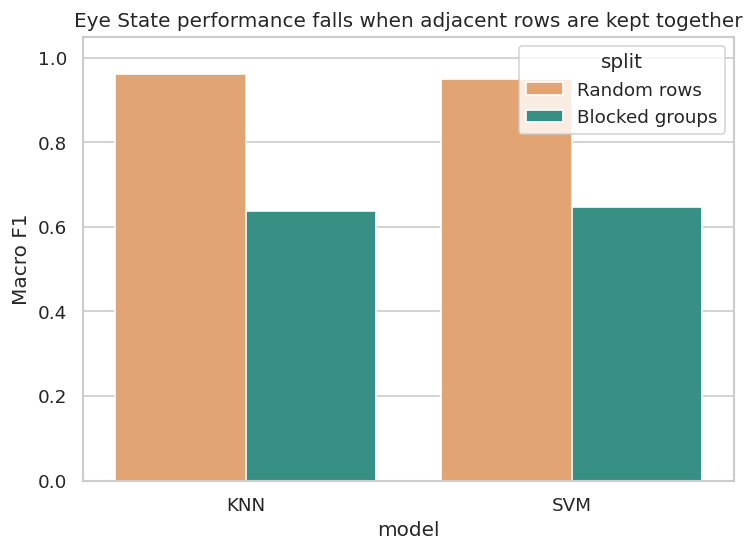

In [14]:
Xe_random_train, Xe_random_test, ye_random_train, ye_random_test = train_test_split(
    X_eye,
    y_eye,
    test_size=0.20,
    stratify=y_eye,
    random_state=RANDOM_STATE,
)

sensitivity_rows = []
for model_name, blocked_model in eye_models.items():
    # Refit the already selected pipeline on a random split only for the leakage check.
    blocked_model.fit(Xe_random_train, ye_random_train)
    random_prediction = blocked_model.predict(Xe_random_test)
    random_f1 = f1_score(ye_random_test, random_prediction, average="macro")
    blocked_f1 = metrics.loc[
        (metrics["dataset"] == "EEG Eye State")
        & (metrics["model"] == model_name),
        "macro_f1",
    ].iloc[0]
    sensitivity_rows.extend([
        {"model": model_name, "split": "Random rows", "macro_f1": random_f1},
        {"model": model_name, "split": "Blocked groups", "macro_f1": blocked_f1},
    ])

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(4))

ax = sns.barplot(
    data=sensitivity,
    x="model",
    y="macro_f1",
    hue="split",
    palette=["#F4A261", "#2A9D8F"],
)
ax.set_ylim(0, 1.05)
ax.set_title("Eye State performance falls when adjacent rows are kept together")
ax.set_ylabel("Macro F1")
plt.tight_layout()
plt.show()

## Takeaways

1. **BEED:** KNN is the stronger model. Its macro F1 is approximately 0.983 and errors are rare across all four balanced classes. SVM reaches approximately 0.819 macro F1 and particularly confuses numeric class 3 with class 2.
2. **EEG Eye State:** Under the more defensible blocked split, both models are only moderately effective. SVM is slightly stronger (about 0.648 macro F1) than KNN (about 0.637), but neither is reliable enough for clinical use.
3. **Feature patterns:** BEED models repeatedly prioritise attributes including X12, X11, X4 and X1. Eye State models repeatedly identify channels such as P7, AF4, T7/T8, O1 and F8. Permutation importance shows predictive association, not medical causation.
4. **Complementarity:** BEED gives direct epilepsy-classification evidence, while Eye State shows how normal EEG state classification behaves. The results are complementary rather than contradictory because the targets are different.
5. **Critical limitation:** Randomly splitting the sequential Eye State rows inflates macro F1 to about 0.95–0.96. The blocked result around 0.64–0.65 is the safer estimate and demonstrates why leakage-aware evaluation matters.